# Lecture : Graph Transformers

## Lab 01 : Vanilla Graph Transformers (GT without Positional Encoding) -- Solution

### Xavier Bresson, Guoji Fu

Dwivedi, Bresson, A generalization of transformer networks to graphs, 2020   
https://arxiv.org/pdf/2012.09699.pdf

In [1]:
# For Google Colaboratory
import sys, os

if "google.colab" in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/07_Graph_Transformers'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !{sys.executable} -m pip install torch==2.8.0 torch-geometric==2.8.0.post1 networkx==3.5 numpy==2.5.3 matplotlib==3.10.6

In [2]:
# Libraries
import math
import sys
import time
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import add_self_loops, degree, from_networkx, softmax, to_networkx

_ = torch.manual_seed(0)
print(
    f"Environment: Python {sys.version.split()[0]}, PyTorch {torch.__version__}, "
    f"PyG {torch_geometric.__version__}, NetworkX {nx.__version__}, "
    f"NumPy {np.__version__}, Matplotlib {plt.matplotlib.__version__}"
)

Environment: Python 3.11.16, PyTorch 2.1.2, PyG 2.5.1, NetworkX 3.1, NumPy 1.24.3, Matplotlib 3.7.1


# Visualize the artificial graph dataset used in this notebook

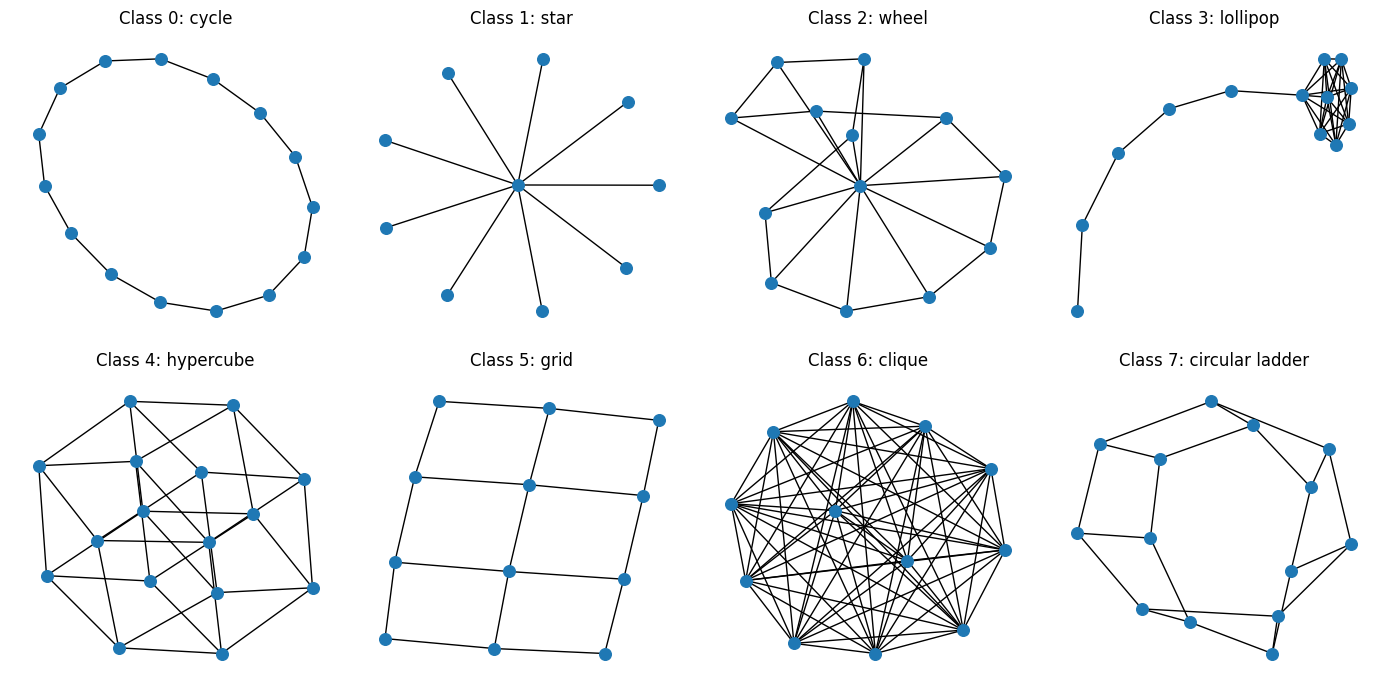

In [3]:
CLASS_NAMES = [
    "cycle", "star", "wheel", "lollipop",
    "hypercube", "grid", "clique", "circular ladder",
]


# Convert a simple undirected NetworkX graph to a PyG Data object.
# PyG stores an undirected edge in both directions in edge_index. We also add
# one self-loop per node, matching the preprocessing in DGL MiniGCDataset.
def networkx_to_pyg(graph, label):
    graph = nx.convert_node_labels_to_integers(graph)
    data = from_networkx(graph)
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.y = torch.tensor([label], dtype=torch.long)
    return data


# Reproduce the eight graph families of DGL MiniGCDataset as PyG Data objects.
def generate_minigc_pyg(num_graphs, min_num_v, max_num_v, seed=0):
    rng = np.random.RandomState(seed)
    dataset = []
    graphs_per_class = num_graphs // 8

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.cycle_graph(num_v), 0))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.star_graph(num_v - 1), 1))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.wheel_graph(num_v), 2))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        path_len = int(rng.randint(2, num_v // 2))
        dataset.append(networkx_to_pyg(nx.lollipop_graph(num_v - path_len, path_len), 3))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dimension = int(math.log(num_v, 2))
        dataset.append(networkx_to_pyg(nx.hypercube_graph(dimension), 4))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        num_rows = int(rng.randint(2, num_v // 2))
        num_cols = num_v // num_rows
        dataset.append(networkx_to_pyg(nx.grid_graph([num_rows, num_cols]), 5))

    for _ in range(graphs_per_class):
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.complete_graph(num_v), 6))

    while len(dataset) < num_graphs:
        num_v = int(rng.randint(min_num_v, max_num_v))
        dataset.append(networkx_to_pyg(nx.circular_ladder_graph(num_v // 2), 7))

    return dataset


dataset = generate_minigc_pyg(8, 10, 20, seed=0)

# visualise the 8 classes of graphs
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for c, ax in enumerate(axes.ravel()):
    graph = to_networkx(dataset[c], to_undirected=True, remove_self_loops=True)
    nx.draw(graph, ax=ax, node_size=70, width=1.0)
    ax.set_title(f"Class {c}: {CLASS_NAMES[c]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Exercise 1: Generate train, val and test datasets

### Question 1.1: Add node features

**Instructions**:

- Obtain the destination nodes from `graph.edge_index[1]`.

- Compute the in-degree of every node with `torch_geometric.utils.degree()`.

- Reshape and convert the in-degrees to a floating-point tensor with shape `(number_of_nodes, 1)`.

- Store the node features in the PyG `Data` object as `graph.x`.

In [4]:
# Add node features to graphs
def add_node_edge_features(dataset):
    for graph in dataset:
        ###############################################
        # YOUR CODE STARTS HERE
        # YOUR CODE
        ###############################################
        dst = graph.edge_index[1]
        graph.x = degree(dst, num_nodes=graph.num_nodes).view(-1, 1).float()
        ###############################################
        # YOUR CODE ENDS HERE
        ###############################################

    return dataset

In [5]:
# Generate independent, deterministic graph datasets.
# Different seeds avoid replaying the same random sequence. However, the legacy
# generator has a very small topology support: an exact isomorphism audit finds
# train-set matches for 93/100 test graphs and 99/100 validation graphs. These
# splits are retained for fidelity; their accuracy is only an execution smoke test.
trainset = generate_minigc_pyg(350, 10, 20, seed=0)
testset = generate_minigc_pyg(100, 10, 20, seed=1)
valset = generate_minigc_pyg(100, 10, 20, seed=2)
trainset = add_node_edge_features(trainset)
testset = add_node_edge_features(testset)
valset = add_node_edge_features(valset)
print(trainset[0])

Data(edge_index=[2, 45], num_nodes=15, y=[1], x=[15, 1])


### Question 1.2: Use the PyG DataLoader to prepare a batch of graphs and test it

**Instructions:**

- Initialize `torch_geometric.loader.DataLoader` with the dataset, batch size, and shuffle flag.

- PyG automatically concatenates graph attributes, offsets `edge_index`, and creates a `batch` vector mapping each node to its graph.

- Graph labels are batched in `batch_graphs.y`; node features are stored in `batch_graphs.x`.

In [6]:
# Construct a PyG data loader.
def make_data_loader(dataset, batch_size, shuffle):
    ###############################################
    # YOUR CODE STARTS HERE
    # YOUR CODE
    ###############################################
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    ###############################################
    # YOUR CODE ENDS HERE
    ###############################################
    return data_loader

In [7]:
# Generate a batch of graphs
batch_size = 10
train_loader = make_data_loader(trainset, batch_size=batch_size, shuffle=True)
batch_graphs = next(iter(train_loader))
batch_labels = batch_graphs.y
print(batch_graphs)
print(batch_labels)
batch_x = batch_graphs.x
print('batch_x:', batch_x.size())
print('batch vector:', batch_graphs.batch.size())

DataBatch(edge_index=[2, 681], num_nodes=135, y=[10], x=[135, 1], batch=[135], ptr=[11])
tensor([2, 2, 4, 7, 2, 7, 7, 3, 5, 3])
batch_x: torch.Size([135, 1])
batch vector: torch.Size([135])


# Exercise 2: Design the class of vanilla GraphTransformer networks with PyG

Node update equation:  
\begin{eqnarray*}
\bar{h}^{\ell} &=& h^{\ell} + \textrm{gMHA} (\textrm{LN}(h^{\ell})) \in \mathbb{R}^{N\times d}\\
h^{\ell+1} &=& \bar{h}^{\ell} + \textrm{MLP} (\textrm{LN}(\bar{h}^{\ell})) \in \mathbb{R}^{N\times d}\\
&&\textrm{with } \textrm{gMHA}(h)=\textrm{Concat}_{k=1}^H \left( \textrm{gHA}(h_k) \right) W_O \in \mathbb{R}^{N\times d},\ h_k\in \mathbb{R}^{N\times d'=d/H}, W_O\in \mathbb{R}^{d\times d} \\
&&\quad\quad\ \textrm{gHA}(h)_i= \sum_{j\in \mathcal{N}_i} \underbrace{\frac{\exp(q_i^T k_j/\sqrt{d'})}{ \sum_{j'\in\mathcal{N}_i} \exp(q_i^T k_{j'}/\sqrt{d'}) }}_{\textrm{graph attention score}_{ij}} v_j\\
&&\quad\quad\ Q=hW_Q, K=hW_K, V=hW_V\in \mathbb{R}^{N\times d},\ \textrm{then reshaped to }\mathbb{R}^{N\times H\times d'}\\
h^{\ell=0} &=& \textrm{LL}(h_0) \in \mathbb{R}^{N\times d}\ \textrm{(input node feature)}
\end{eqnarray*}

The sparse PyG `edge_index` restricts attention to $j\in\mathcal{N}_i$. Every graph contains self-loops, so $i\in\mathcal{N}_i$.

### Implement a MLP layer for classification

In [8]:
# class MLP layer for classification
class MLP_layer(nn.Module):

    def __init__(self, input_dim, output_dim, L=2): # L = nb of hidden layers
        super(MLP_layer, self).__init__()
        list_FC_layers = [ nn.Linear( input_dim, input_dim, bias=True ) for l in range(L) ]
        list_FC_layers.append(nn.Linear( input_dim, output_dim , bias=True ))
        self.FC_layers = nn.ModuleList(list_FC_layers)
        self.L = L

    def forward(self, x):
        y = x
        for l in range(self.L):
            y = self.FC_layers[l](y)
            y = torch.relu(y)
        y = self.FC_layers[self.L](y)
        return y

### Question 2.1: Implement a Graph Multi-Head Attention (MHA) Layer with PyG

**Instructions:**

- Subclass PyG `MessagePassing`. Use `flow='source_to_target'` and `node_dim=0`, because `Q`, `K`, and `V` have shape `(N, H, d')`.

- In `message()`, PyG supplies destination queries `Q_i` and source keys/values `K_j`, `V_j` for every edge $j\to i$.

- Compute scaled dot-product logits $q_i^T k_j/\sqrt{d'}$ with shape `(E, H)`.

- Normalize the logits independently over the incoming neighbors of every destination node and every head. Use `torch_geometric.utils.softmax(..., index=index)`.

- Return the attention-weighted values. The `MessagePassing` base class sums them at each destination node.

- In `forward()`, project and reshape `Q`, `K`, and `V`, then call `propagate()`.

Do not call `TransformerConv`, `GATConv`, or another prebuilt attention layer: the purpose of this exercise is to implement graph-restricted multi-head attention.

In [9]:
# class graph multi head attention layer
class graph_MHA_layer(MessagePassing): # MHA = Multi Head Attention

    def __init__(self, hidden_dim, head_hidden_dim, num_heads): # hidden_dim = d
        # Q, K, V have shape (N, H, d'), so the node dimension is dimension 0.
        super().__init__(aggr='add', flow='source_to_target', node_dim=0)
        self.head_hidden_dim = head_hidden_dim # head_hidden_dim = d' = d/H
        self.num_heads = num_heads # number of heads = H
        self.WQ = nn.Linear(hidden_dim, head_hidden_dim * num_heads, bias=True)
        self.WK = nn.Linear(hidden_dim, head_hidden_dim * num_heads, bias=True)
        self.WV = nn.Linear(hidden_dim, head_hidden_dim * num_heads, bias=True)

    def message(self, Q_i, K_j, V_j, index, ptr, size_i):
        ###############################################
        # YOUR CODE STARTS HERE
        # YOUR CODE
        ###############################################
        attention_logits = (Q_i * K_j).sum(dim=-1) / math.sqrt(self.head_hidden_dim)
        attention = softmax(attention_logits, index=index, ptr=ptr, num_nodes=size_i)
        weighted_vj = attention.unsqueeze(-1) * V_j
        ###############################################
        # YOUR CODE ENDS HERE
        ###############################################
        return weighted_vj

    def forward(self, x, edge_index):
        Q = self.WQ(x) # size=(N, d)
        K = self.WK(x) # size=(N, d)
        V = self.WV(x) # size=(N, d)

        ###############################################
        # YOUR CODE STARTS HERE
        # YOUR CODE
        ###############################################
        Q = Q.view(-1, self.num_heads, self.head_hidden_dim)
        K = K.view(-1, self.num_heads, self.head_hidden_dim)
        V = V.view(-1, self.num_heads, self.head_hidden_dim)
        ###############################################
        # YOUR CODE ENDS HERE
        ###############################################

        ###############################################
        # YOUR CODE STARTS HERE
        # YOUR CODE
        ###############################################
        gMHA = self.propagate(edge_index, Q=Q, K=K, V=V)
        ###############################################
        # YOUR CODE ENDS HERE
        ###############################################
        return gMHA

### Implement a GraphTransformer layer

In [10]:
# class GraphTransformer layer
class GraphTransformer_layer(nn.Module):

    def __init__(self, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        assert hidden_dim % num_heads == 0
        self.hidden_dim = hidden_dim # hidden_dim = d
        self.num_heads = num_heads # number of heads = H
        self.dropout_mha = nn.Dropout(dropout)
        self.dropout_mlp = nn.Dropout(dropout)
        self.gMHA = graph_MHA_layer(hidden_dim, hidden_dim // num_heads, num_heads)
        self.WO = nn.Linear(hidden_dim, hidden_dim)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        # Self-attention layer
        h_rc = x # size=(N,d), for residual connection
        h = self.layer_norm1(x)
        h_MHA = self.gMHA(h, edge_index) # size=(N,H,d')
        h_MHA = h_MHA.reshape(-1, self.hidden_dim)
        h_MHA = self.dropout_mha(h_MHA)
        h_MHA = self.WO(h_MHA)
        h = h_rc + h_MHA

        # Fully-connected layer
        h_rc = h
        h = self.layer_norm2(h)
        h_MLP = self.linear1(h)
        h_MLP = torch.relu(h_MLP)
        h_MLP = self.dropout_mlp(h_MLP)
        h_MLP = self.linear2(h_MLP)
        h = h_rc + h_MLP

        return h

### Question 2.2: Combine the MLP and GraphTransformer layers to construct the Graph Transformer network

**Instructions:**

- *Input embedding layer:* Initialize `nn.Linear()` to convert input features into node embeddings.

- *Graph Transformer layers:* Initialize an `nn.ModuleList()` containing `L` instances of `GraphTransformer_layer()`.

- *MLP layer:* Initialize `MLP_layer()` for graph classification.

- In `forward()`, apply the embedding and Graph Transformer layers, use `global_mean_pool(h, data.batch)` to obtain graph representations, and classify them with the MLP.

In [11]:
# class Graph Transformer network
class GraphTransformer_net(nn.Module):

    def __init__(self, net_parameters):
        super().__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        num_heads = net_parameters['num_heads']
        L = net_parameters['L']

        ###############################################
        # YOUR CODE STARTS HERE
        # YOUR CODE
        ###############################################
        self.embedding_h = nn.Linear(input_dim, hidden_dim)
        self.GraphTransformer_layers = nn.ModuleList([
            GraphTransformer_layer(hidden_dim, num_heads) for _ in range(L)
        ])
        self.MLP_layer = MLP_layer(hidden_dim, output_dim)
        ###############################################
        # YOUR CODE ENDS HERE
        ###############################################

    def forward(self, data):
        ###############################################
        # YOUR CODE STARTS HERE
        # YOUR CODE
        ###############################################
        h = self.embedding_h(data.x)

        for GT_layer in self.GraphTransformer_layers:
            h = GT_layer(h, data.edge_index)

        y = global_mean_pool(h, data.batch)
        y = self.MLP_layer(y)
        ###############################################
        # YOUR CODE ENDS HERE
        ###############################################
        return y

### Instantiate a graph Transformer network

In [12]:
# Instantiate one network (testing)
net_parameters = {}
net_parameters['input_dim'] = 1
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 8 # nb of classes
net_parameters['num_heads'] = 8
net_parameters['L'] = 4
net = GraphTransformer_net(net_parameters)
print(net)


def display_num_param(net):
    nb_param = sum(param.numel() for param in net.parameters())
    print('Number of parameters: {} ({:.2f} million)'.format(nb_param, nb_param / 1e6))
    return nb_param / 1e6


_ = display_num_param(net)
batch_size = 10
train_loader = make_data_loader(trainset, batch_size=batch_size, shuffle=True)
batch_graphs = next(iter(train_loader))
batch_scores = net(batch_graphs)
print(batch_scores.size())

GraphTransformer_net(
  (embedding_h): Linear(in_features=1, out_features=128, bias=True)
  (GraphTransformer_layers): ModuleList(
    (0-3): 4 x GraphTransformer_layer(
      (dropout_mha): Dropout(p=0.0, inplace=False)
      (dropout_mlp): Dropout(p=0.0, inplace=False)
      (gMHA): graph_MHA_layer()
      (WO): Linear(in_features=128, out_features=128, bias=True)
      (layer_norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (layer_norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (linear1): Linear(in_features=128, out_features=128, bias=True)
      (linear2): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (MLP_layer): MLP_layer(
    (FC_layers): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=8, bias=True)
    )
  )
)
Number of parameters: 432648 (0.43 million)
torch.Size([10, 8])


# Train the network

### Define the accuracy function to compute the prediction accuracy

In [13]:
def accuracy(scores, targets):
    scores = scores.detach().argmax(dim=1)
    acc = (scores==targets).float().sum().item()
    return acc

### Implement the ```run_one_epoch``` function for training and evaluation

In [14]:
def run_one_epoch(net, data_loader, train=True, loss_fc=None, optimizer=None):
    if train:
        net.train() # during training
    else:
        net.eval()  # during inference/test

    epoch_loss = 0.0
    epoch_acc = 0.0
    nb_data = 0

    for batch_graphs in data_loader:
        batch_labels = batch_graphs.y
        batch_scores = net(batch_graphs)
        loss = loss_fc(batch_scores, batch_labels)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_count = batch_labels.size(0)
        epoch_loss += loss.detach().item() * batch_count
        epoch_acc += accuracy(batch_scores, batch_labels)
        nb_data += batch_count

    epoch_loss /= nb_data
    epoch_acc /= nb_data
    return epoch_loss, epoch_acc, optimizer

### Set up data loaders, initialize the model, and running the training loop for the graph Transformer network

In [15]:
# dataset loaders
train_loader = make_data_loader(trainset, batch_size=50, shuffle=True)
test_loader = make_data_loader(testset, batch_size=50, shuffle=False)
val_loader = make_data_loader(valset, batch_size=50, shuffle=False)

# Instantiate one network
_ = torch.manual_seed(0)
net_parameters = {}
net_parameters['input_dim'] = 1
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 8 # nb of classes
net_parameters['num_heads'] = 8
net_parameters['L'] = 4
net = GraphTransformer_net(net_parameters)
_ = display_num_param(net)

# optimizer
loss_fc = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.0003)

# training loop
for epoch in range(50):
    start = time.time()
    epoch_train_loss, epoch_train_acc, optimizer = run_one_epoch(
        net, train_loader, True, loss_fc, optimizer
    )
    with torch.no_grad():
        epoch_val_loss, epoch_val_acc, _ = run_one_epoch(net, val_loader, False, loss_fc)
    print('Epoch {}, time {:.4f}, train_loss: {:.4f}, val_loss: {:.4f}'.format(
        epoch, time.time() - start, epoch_train_loss, epoch_val_loss))
    print('                       train_acc: {:.4f}, val_acc: {:.4f}'.format(
        epoch_train_acc, epoch_val_acc))

# Final evaluation with fixed, non-shuffled loaders. The test set is used here
# for the first and only time in the training/evaluation pipeline.
train_eval_loader = make_data_loader(trainset, batch_size=50, shuffle=False)
with torch.no_grad():
    final_train_loss, final_train_acc, _ = run_one_epoch(net, train_eval_loader, False, loss_fc)
    final_val_loss, final_val_acc, _ = run_one_epoch(net, val_loader, False, loss_fc)
    final_test_loss, final_test_acc, _ = run_one_epoch(net, test_loader, False, loss_fc)
print('Final evaluation (test used once): train_acc: {:.4f}, val_acc: {:.4f}, test_acc: {:.4f}'.format(
    final_train_acc, final_val_acc, final_test_acc))

Number of parameters: 432648 (0.43 million)
Epoch 0, time 0.2726, train_loss: 2.0158, val_loss: 1.8763
                       train_acc: 0.1457, val_acc: 0.1200
Epoch 1, time 0.1856, train_loss: 1.8221, val_loss: 1.7430
                       train_acc: 0.2371, val_acc: 0.2800
Epoch 2, time 0.2205, train_loss: 1.7037, val_loss: 1.6291
                       train_acc: 0.3400, val_acc: 0.5900
Epoch 3, time 0.2919, train_loss: 1.5817, val_loss: 1.5101
                       train_acc: 0.6143, val_acc: 0.5600
Epoch 4, time 0.1980, train_loss: 1.4535, val_loss: 1.3736
                       train_acc: 0.6257, val_acc: 0.7000
Epoch 5, time 0.2072, train_loss: 1.2936, val_loss: 1.2204
                       train_acc: 0.7314, val_acc: 0.7300
Epoch 6, time 0.2057, train_loss: 1.1226, val_loss: 1.0414
                       train_acc: 0.6886, val_acc: 0.7600
Epoch 7, time 0.1877, train_loss: 0.9516, val_loss: 0.8823
                       train_acc: 0.8257, val_acc: 0.8300
Epoch 8, time 0.1851

## Results and interpretation

The following values are retained from the original course comparison table. They were not produced with a documented common split, checkpoint, or evaluation protocol, so they are **historical references only** and must not be used to rank the models.

| Historical model | train acc | test acc |
| --- | ---: | ---: |
| GCN | 0.7829 | 0.7900 |
| GIN | 0.0800 | 0.1000 |
| GAT | 0.9229 | 0.9400 |

The current deterministic run evaluates the test set only once, after the fixed 50-epoch training schedule.

| Current model | train acc | validation acc | test acc |
| --- | ---: | ---: | ---: |
| Vanilla GT | 0.9229 | 0.9300 | 0.9600 |

**Interpretation:** the legacy synthetic generator has substantial cross-split topology overlap (93/100 test graphs and 99/100 validation graphs have a same-label isomorphic match in training). Treat these accuracies only as an implementation smoke test, not as evidence of generalization.